## **Exercise**

1. Load the [dataset](https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset) from Kaggle. Use the "hour.csv" file.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
color_pal = sns.color_palette()
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the dataset
df=pd.read_csv("hour.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [ ]:
df['dteday'] = pd.to_datetime(df['dteday'])

# Create full datetime column
df['datetime'] = df['dteday'] + pd.to_timedelta(df['hr'], unit='h')

df = df.sort_values('datetime')
df = df.set_index('datetime')

<Axes: title={'center': 'Hourly Bike Rentals'}, xlabel='datetime'>

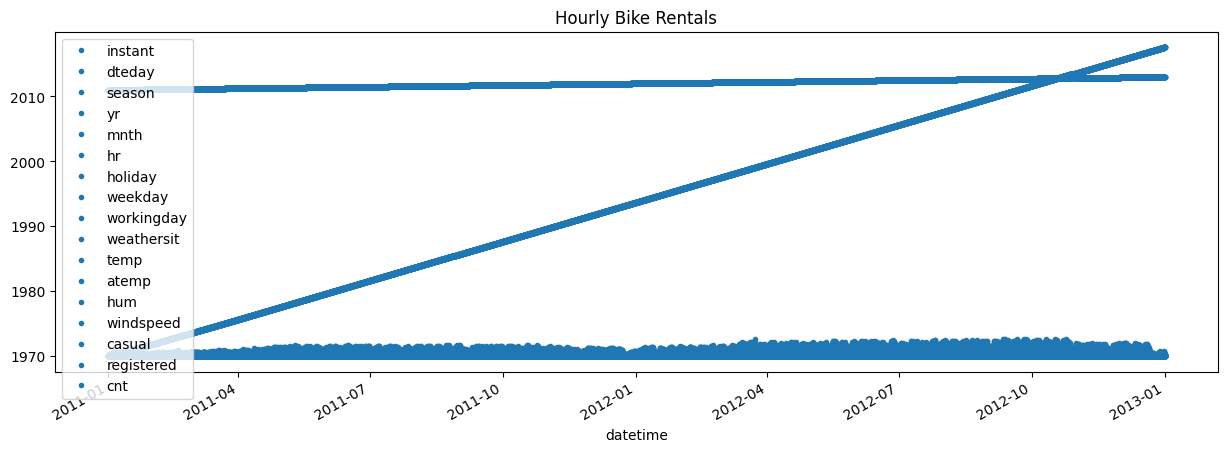

In [ ]:
df.plot(
    style=".", figsize=(15, 5),
    color=color_pal[0],
    title="Hourly Bike Rentals"
)
# plt.show()

2. Visualize the structure of the dataset using appropriate libraries and plots.

In [ ]:

df.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


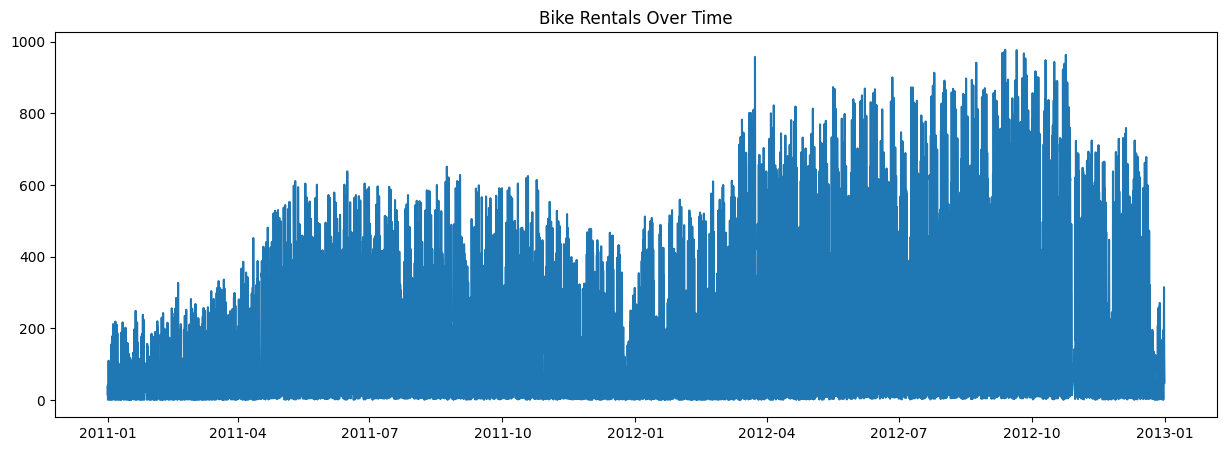

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['cnt'])
plt.title("Bike Rentals Over Time")
plt.show()

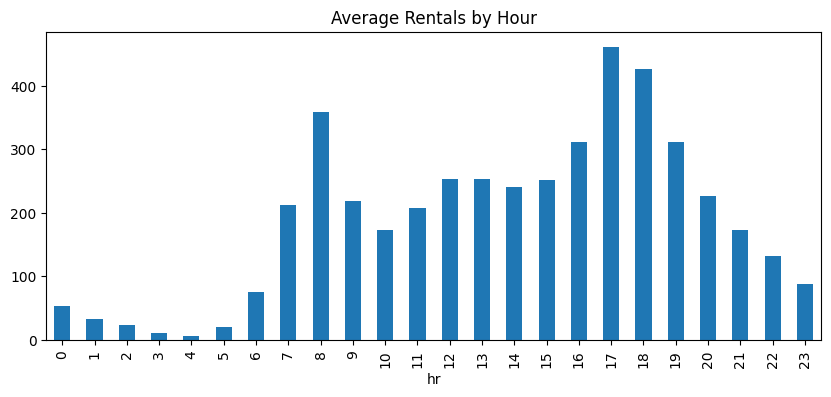

In [ ]:
df.groupby("hr")["cnt"].mean().plot(kind='bar', figsize=(10,4))
plt.title("Average Rentals by Hour")
plt.show() 

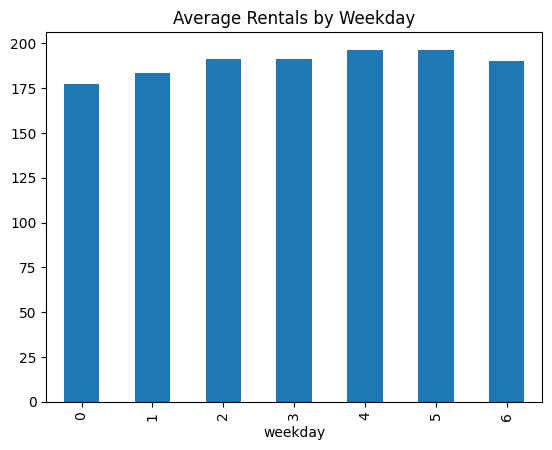

In [ ]:
df.groupby("weekday")["cnt"].mean().plot(kind='bar')
plt.title("Average Rentals by Weekday")
plt.show()

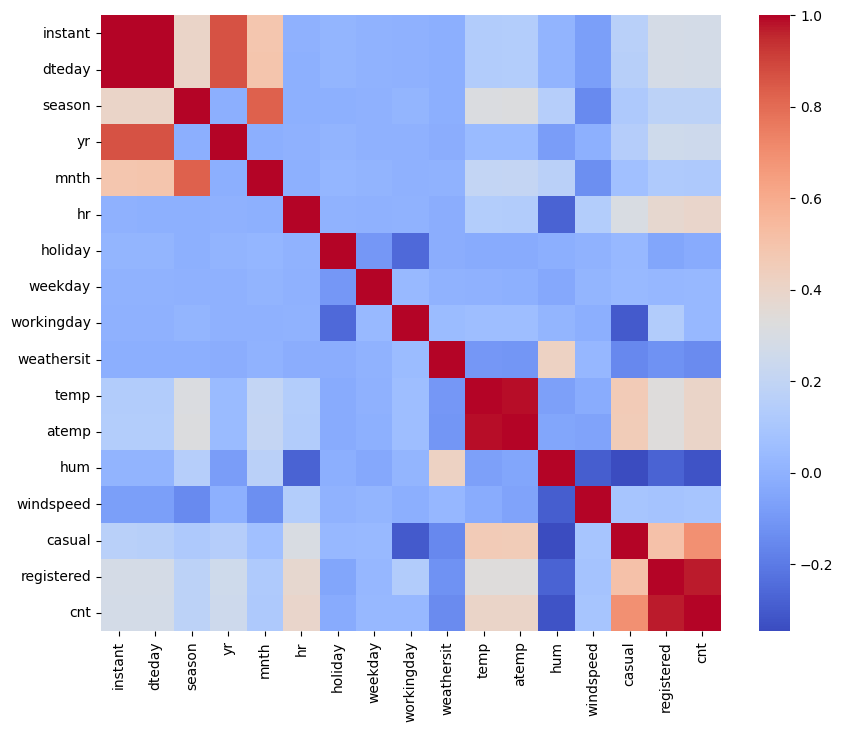

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

3. Clean and pre-process the dataset as required and prepare the data for modelling.

In [ ]:
df = df.drop(columns=["instant", "dteday"])

# One-hot encoding for categorical variables
df = pd.get_dummies(df, columns=["season", "weathersit", "weekday", "hr"], drop_first=True)




4. Create the lag and rolling windows features for the "cnt" column such as: 1 day lag, 1 week lag, 1 month, etc. and last 3 day rolling mean, last 3 hours rolling mean, etc. But it should be based on your dataset and what makes sense for this dataset.

  

Lag features

In [ ]:
# 1 day lag = 24 hours
# 1 week lag = 24 × 7 = 168
# 1 month lag ≈ 24 × 30 = 720

df['lag_24'] = df['cnt'].shift(24)
df['lag_168'] = df['cnt'].shift(168)
df['lag_720'] = df['cnt'].shift(720)


# Last 3 hours
df['roll_3h'] = df['cnt'].shift(1).rolling(window=3).mean()

# Last 24 hours
df['roll_24h'] = df['cnt'].shift(1).rolling(window=24).mean()

# Last 3 days
df['roll_72h'] = df['cnt'].shift(1).rolling(window=72).mean()

In [ ]:
df = df.dropna().copy()

5. Implement linear regression to predict how many bikes will be rented each hour of the last week and evaluate using appropriate metrics.


In [ ]:
# slpit data into train and test sets
from sklearn.model_selection import train_test_split

# Last week = last 168 hours
test_size = 168

train = df.iloc[:-test_size]
test = df.iloc[-test_size:]

X_train = train.drop("cnt", axis=1)
y_train = train["cnt"]

X_test = test.drop("cnt", axis=1)
y_test = test["cnt"]

In [ ]:
# train model
from sklearn.linear_model import LinearRegression

# initialize the linear regression model
lr = LinearRegression()

# train the model
lr.fit(X_train, y_train)

# make predictions
y_pred_lr = lr.predict(X_test)

In [ ]:
# evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 2.7172113765366084e-13
Linear Regression RMSE: 3.245175917629009e-13


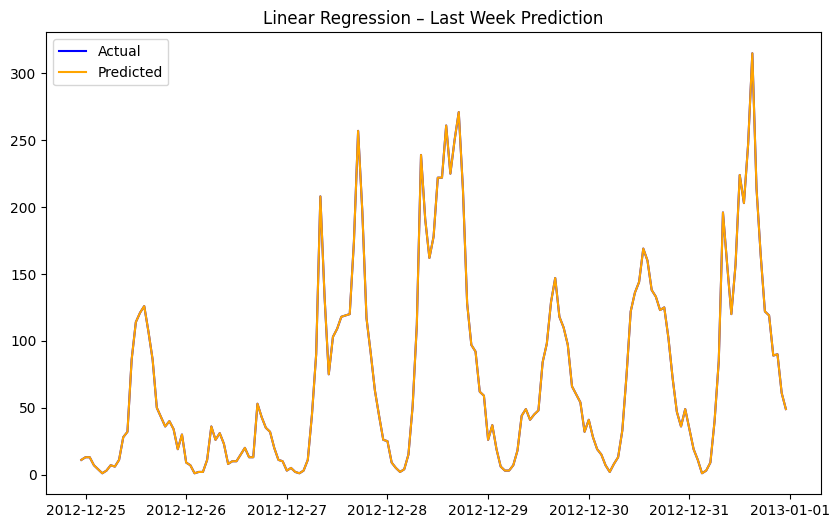

In [ ]:
# plot actual vs predicted
plt.figure(figsize=(10,6))
plt.plot(y_test.index,y_test.values, label='Actual',color='blue')
plt.plot(y_test.index,y_pred_lr, label='Predicted',color='orange')
plt.legend()
plt.title("Linear Regression – Last Week Prediction")
plt.show()

6. Implement XGBoost to predict how many bikes will be rented each hour of the last week and evaluate using appropriate metrics.


In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [ ]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 1.736950159072876
XGBoost RMSE: 3.0466446227007262
